# 오프라인 POS 데이터 EDA + 상품 네트워크 분석 v3 (전체 기간)
- 데이터: `B2_POS_SALE_H1.csv` + `B2_POS_SALE_H2.csv` (오프라인 영수증 POS)
- 상품정보: `B4_ITEM_DV_INFO.csv`
- 분석 기간: **2025년 1~12월 (연간 전체)**
- 분석 대상: 편의점 주요 중분류 43종
- 목적: 퀵커머스(온라인) 네트워크와 비교

## 0. 라이브러리 & 설정

In [1]:
!pip install networkx -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\eun03\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 분석 대상 중분류
TARGET_CATEGORIES = [
    '도시락', '김밥', '비스킷류', '삼각김밥', '샌드위치', '간식빵', '스낵류',
    '초콜릿', '햄버거', '젤리류', '양주', '용기면', '냉장베이커리', '초밥류',
    '기능성드링크', '냉장간식', '하이볼', '프로틴음료', '컵커피', '요구르트',
    '가공우유', '차음료', '호빵', '냉장피자', '샐러드', '냉장간편식', '푸드간편식',
    '젤리', '프로틴/시리얼', '즉석치킨', '냉장주스', '커피음료', '흰우유',
    '즉석조리', '가공미반류', '오징어', '떡', '냉동만두', '스낵안주',
    '상온간편식', '건해산물', '커피', '캔'
]

# 상품정보 로드 & 대상 상품코드 추출
item_info = pd.read_csv('data/B4_ITEM_DV_INFO.csv', encoding='utf-8', low_memory=False)
item_info['ITEM_CD'] = item_info['ITEM_CD'].astype(str).str.strip()

target_items = item_info.loc[
    item_info['ITEM_MDDV_NM'].isin(TARGET_CATEGORIES), 'ITEM_CD'
].unique().tolist()

print(f"분석 대상 중분류: {len(TARGET_CATEGORIES)}종")
print(f"대상 상품코드(SKU) 수: {len(target_items):,}개")

분석 대상 중분류: 43종
대상 상품코드(SKU) 수: 47,230개


## 1. 데이터 로드 (전체 기간)

In [3]:
# POS 데이터 청크로 읽어서 전체 기간 + 대상 상품만 필터링 (H1 + H2)
target_set = set(target_items)

def load_pos_file(path):
    chunks = []
    for chunk in pd.read_csv(path, encoding='utf-8', low_memory=False, chunksize=500_000):
        chunk['ITEM_CODE'] = chunk['ITEM_CODE'].astype(str).str.strip()
        chunk['SALE_AMT'] = chunk['SALE_AMT'].astype(str).str.replace(',', '').astype(float)
        chunk['SALE_QTY'] = pd.to_numeric(chunk['SALE_QTY'], errors='coerce')
        filtered = chunk[chunk['ITEM_CODE'].isin(target_set)]
        if len(filtered) > 0:
            chunks.append(filtered)
    return pd.concat(chunks, ignore_index=True)

print("H1 로드 중...")
df_h1 = load_pos_file('data/B2_POS_SALE_H1.csv')
print(f"  H1 행 수: {len(df_h1):,}")

print("H2 로드 중...")
df_h2 = load_pos_file('data/B2_POS_SALE_H2.csv')
print(f"  H2 행 수: {len(df_h2):,}")

df = pd.concat([df_h1, df_h2], ignore_index=True)
print(f"\n전체 합산 행 수: {len(df):,}")

H1 로드 중...
  H1 행 수: 16,404,725
H2 로드 중...
  H2 행 수: 17,697,444

전체 합산 행 수: 34,102,169


In [4]:
# 파생변수 & 상품정보 JOIN
df['SALE_DATE_DT'] = pd.to_datetime(df['SALE_DATE'].astype(str), format='%Y%m%d')
df['WEEKDAY'] = df['SALE_DATE_DT'].dt.day_name()
df['HOUR'] = df['SALE_TIME'].astype(str).str.zfill(6).str[:2].astype(int)
df['MONTH'] = df['SALE_DATE_DT'].dt.month

df = df.merge(
    item_info[['ITEM_CD', 'ITEM_NM', 'ITEM_LRDV_NM', 'ITEM_MDDV_NM', 'ITEM_SMDV_NM']],
    left_on='ITEM_CODE', right_on='ITEM_CD',
    how='left'
)

print(f"상품명 매칭률: {df['ITEM_NM'].notna().mean():.1%}")
df.head(3)

상품명 매칭률: 100.0%


,SALE_DATE,SALE_TIME,STORE_CODE,POS_NO,TRADE_NO,ITEM_CODE,SALE_QTY,SALE_AMT,SALE_DATE_DT,WEEKDAY,HOUR,MONTH,ITEM_CD,ITEM_NM,ITEM_LRDV_NM,ITEM_MDDV_NM,ITEM_SMDV_NM
0,20250523,143425,17796,1,59106,117969,1.0,1200.0,2025-05-23,Friday,14,5,117969,오리온)고소미70g,과자,비스킷류,크래커
1,20250523,145747,54630,2,3156,124518,1.0,1200.0,2025-05-23,Friday,14,5,124518,오리온)코코망고알맹이67g,과자,젤리류,국산젤리
2,20250523,165556,18467,1,491,116368,1.0,1700.0,2025-05-23,Friday,16,5,116368,오리온)꼬북칩콘스프맛80g,과자,스낵류,옥수수스낵


## 2. EDA

### 2-1. 기본 통계

In [5]:
TX_KEY = ['STORE_CODE', 'POS_NO', 'TRADE_NO', 'SALE_DATE']

print(f"총 판매 라인 수:  {len(df):,}")
print(f"점포 수:          {df['STORE_CODE'].nunique():,}")
print(f"상품(SKU) 수:     {df['ITEM_CODE'].nunique():,}")
print(f"거래(영수증) 수:  {df.groupby(TX_KEY).ngroups:,}")
print(f"분석 기간:        {df['SALE_DATE'].min()} ~ {df['SALE_DATE'].max()}")
print(f"거래당 평균 매출: {df.groupby(TX_KEY)['SALE_AMT'].sum().mean():,.0f}원")

총 판매 라인 수:  34,102,169
점포 수:          454
상품(SKU) 수:     4,663
거래(영수증) 수:  22,491,420
분석 기간:        20250101 ~ 20251231
거래당 평균 매출: 3,782원


### 2-2. 월별 판매 추이

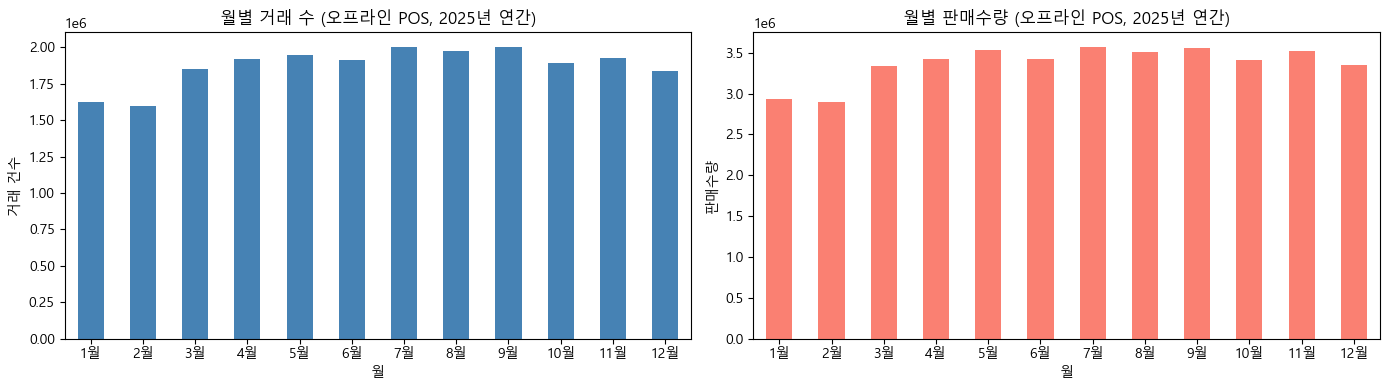

In [6]:
# 월별 거래 수 & 판매수량 추이
monthly_tx = df.groupby('MONTH').apply(lambda x: x.groupby(TX_KEY).ngroups)
monthly_qty = df.groupby('MONTH')['SALE_QTY'].sum()
month_labels = [f"{m}월" for m in monthly_tx.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

monthly_tx.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('월별 거래 수 (오프라인 POS, 2025년 연간)')
axes[0].set_xlabel('월')
axes[0].set_ylabel('거래 건수')
axes[0].set_xticklabels(month_labels, rotation=0)

monthly_qty.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('월별 판매수량 (오프라인 POS, 2025년 연간)')
axes[1].set_xlabel('월')
axes[1].set_ylabel('판매수량')
axes[1].set_xticklabels(month_labels, rotation=0)

plt.tight_layout()
plt.show()

### 2-3. 시간대 / 요일별 거래량

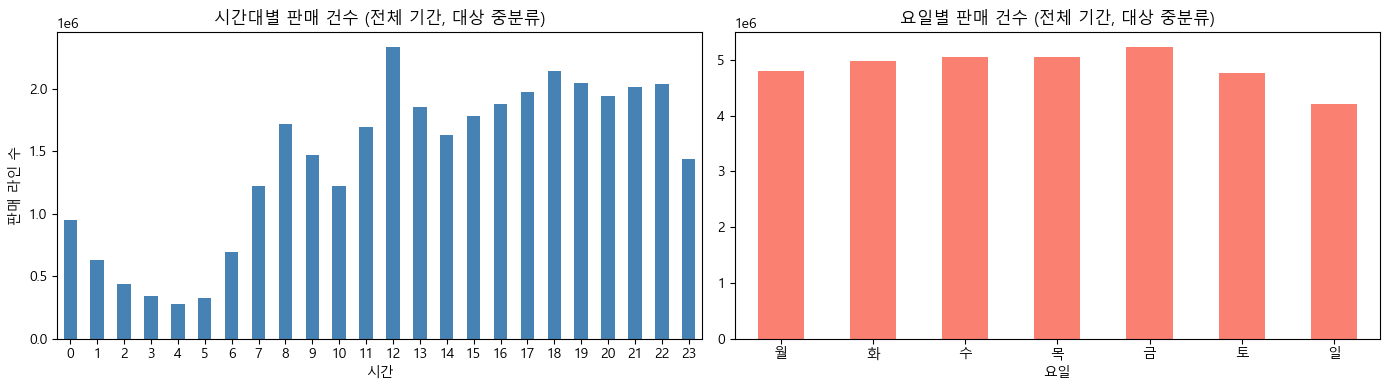

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 시간대별
df.groupby('HOUR')['TRADE_NO'].count().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('시간대별 판매 건수 (전체 기간, 대상 중분류)')
axes[0].set_xlabel('시간')
axes[0].set_ylabel('판매 라인 수')
axes[0].tick_params(axis='x', rotation=0)

# 요일별
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_label = ['월','화','수','목','금','토','일']
weekly = df.groupby('WEEKDAY')['TRADE_NO'].count().reindex(day_order)
weekly.index = day_label
weekly.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('요일별 판매 건수 (전체 기간, 대상 중분류)')
axes[1].set_xlabel('요일')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 2-4. 장바구니 크기(Basket Size) 분포

=== 장바구니 크기 통계 (대상 중분류 기준) ===
count    2.249142e+07
mean     1.516230e+00
std      1.025388e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.500000e+02

  1개: 67.4%
  2개: 22.0%
  3개: 6.4%
  4개: 2.3%
  5개 이상: 1.9%


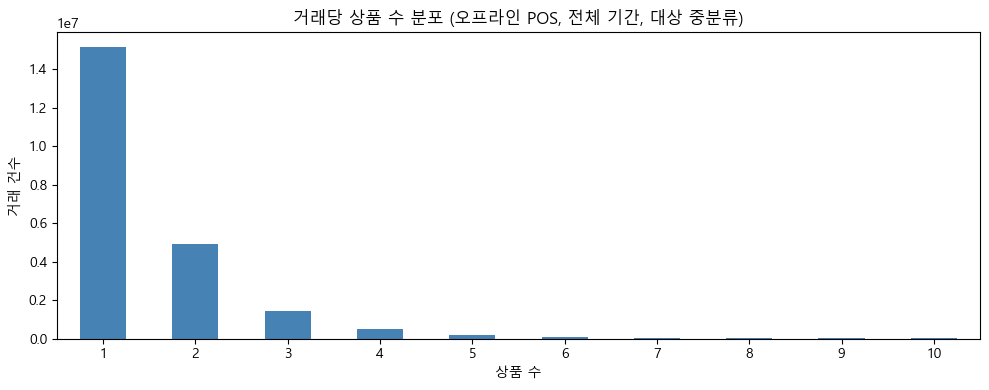

In [8]:
# 대상 중분류 상품이 포함된 거래 전체 기준 basket size
basket_size = df.groupby(TX_KEY)['ITEM_CODE'].count()

print("=== 장바구니 크기 통계 (대상 중분류 기준) ===")
print(basket_size.describe().to_string())
print()
for n, label in [(1,'1개'), (2,'2개'), (3,'3개'), (4,'4개')]:
    print(f"  {label}: {(basket_size == n).mean():.1%}")
print(f"  5개 이상: {(basket_size >= 5).mean():.1%}")

fig, ax = plt.subplots(figsize=(10, 4))
basket_size.clip(upper=10).value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('거래당 상품 수 분포 (오프라인 POS, 전체 기간, 대상 중분류)')
ax.set_xlabel('상품 수')
ax.set_ylabel('거래 건수')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### 2-5. 결제금액 분포

=== 거래당 결제금액 통계 ===
count    2.249142e+07
mean     3.782100e+03
std      7.027963e+03
min     -5.066000e+06
25%      1.800000e+03
50%      2.700000e+03
75%      4.500000e+03
max      6.056000e+06

10,000원 이상 거래 비율: 5.1%
15,000원 이상 거래 비율: 1.9%  ← 퀵커머스 최소주문금액 기준


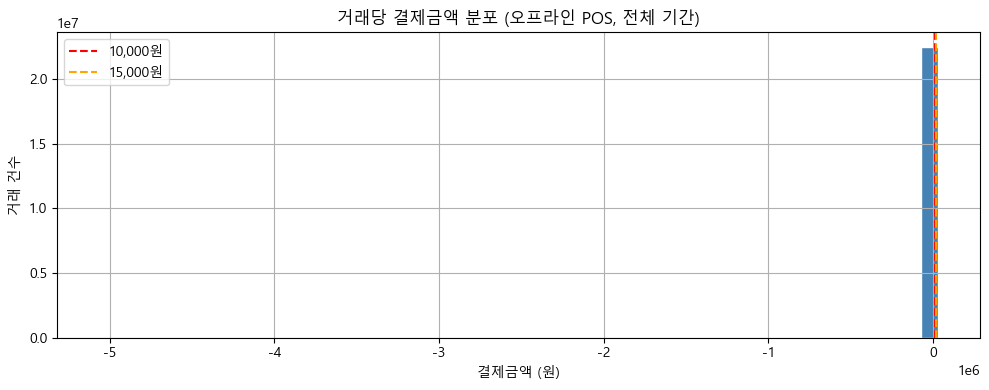

In [9]:
basket_amt = df.groupby(TX_KEY)['SALE_AMT'].sum()

print("=== 거래당 결제금액 통계 ===")
print(basket_amt.describe().to_string())
print()
print(f"10,000원 이상 거래 비율: {(basket_amt >= 10000).mean():.1%}")
print(f"15,000원 이상 거래 비율: {(basket_amt >= 15000).mean():.1%}  ← 퀵커머스 최소주문금액 기준")

fig, ax = plt.subplots(figsize=(10, 4))
basket_amt.clip(upper=30000).hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(10000, color='red', linestyle='--', label='10,000원')
ax.axvline(15000, color='orange', linestyle='--', label='15,000원')
ax.set_title('거래당 결제금액 분포 (오프라인 POS, 전체 기간)')
ax.set_xlabel('결제금액 (원)')
ax.set_ylabel('거래 건수')
ax.legend()
plt.tight_layout()
plt.show()

### 2-6. 중분류별 판매량

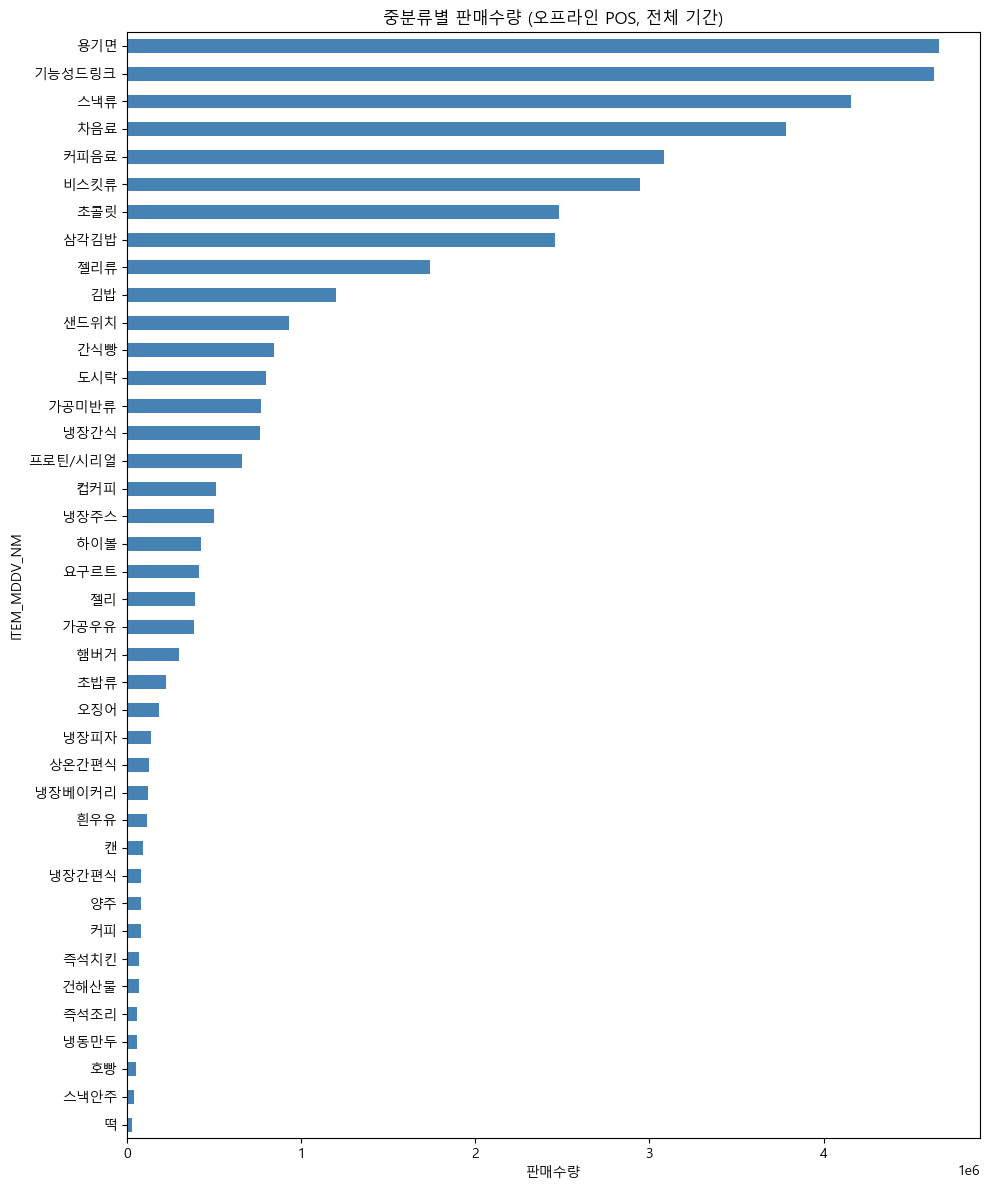

In [10]:
# 중분류별 판매수량
cat_qty = df.groupby('ITEM_MDDV_NM')['SALE_QTY'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
cat_qty.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('중분류별 판매수량 (오프라인 POS, 전체 기간)')
ax.set_xlabel('판매수량')
plt.tight_layout()
plt.show()

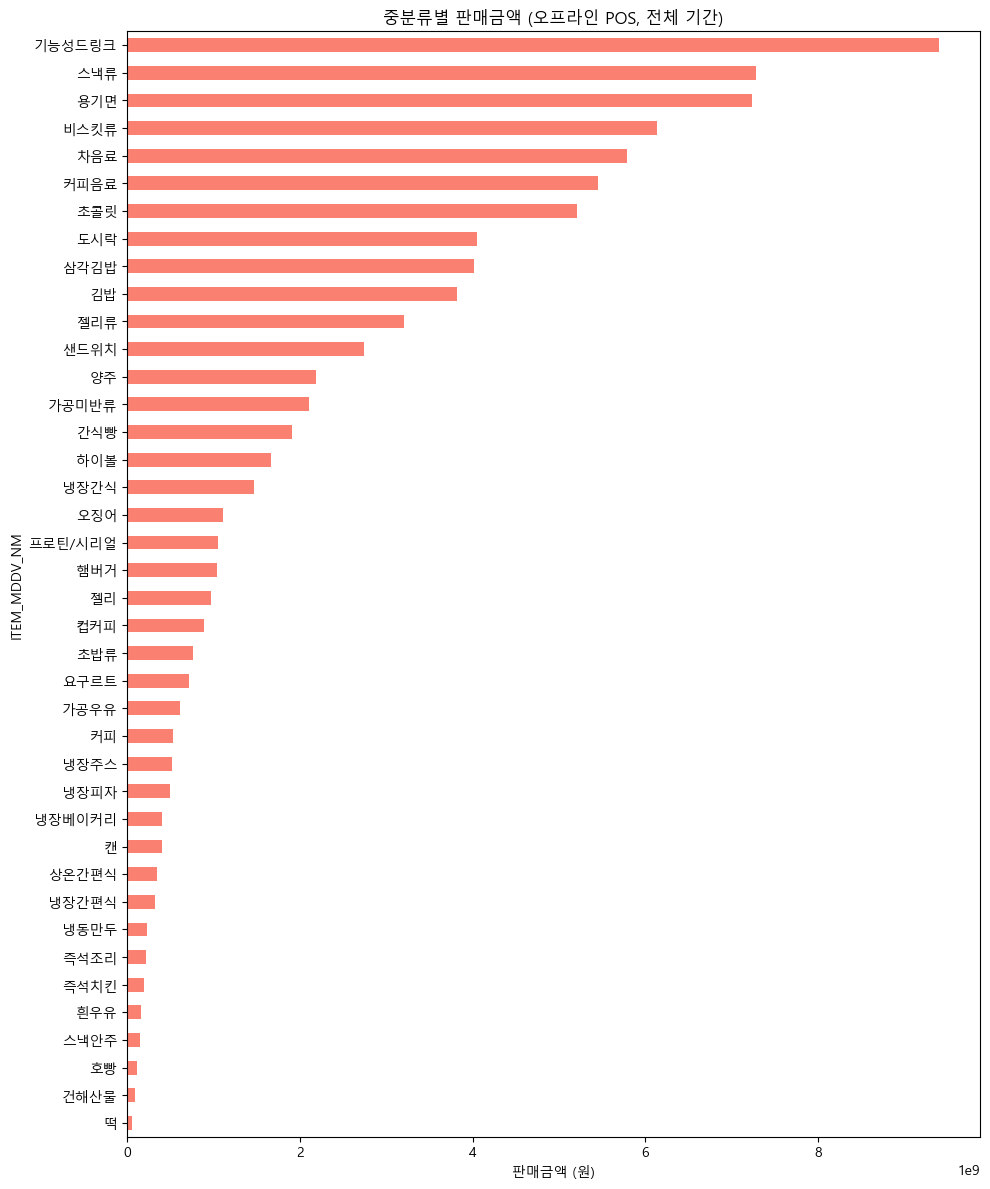

In [11]:
# 중분류별 판매금액
cat_amt = df.groupby('ITEM_MDDV_NM')['SALE_AMT'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
cat_amt.plot(kind='barh', ax=ax, color='salmon')
ax.set_title('중분류별 판매금액 (오프라인 POS, 전체 기간)')
ax.set_xlabel('판매금액 (원)')
plt.tight_layout()
plt.show()

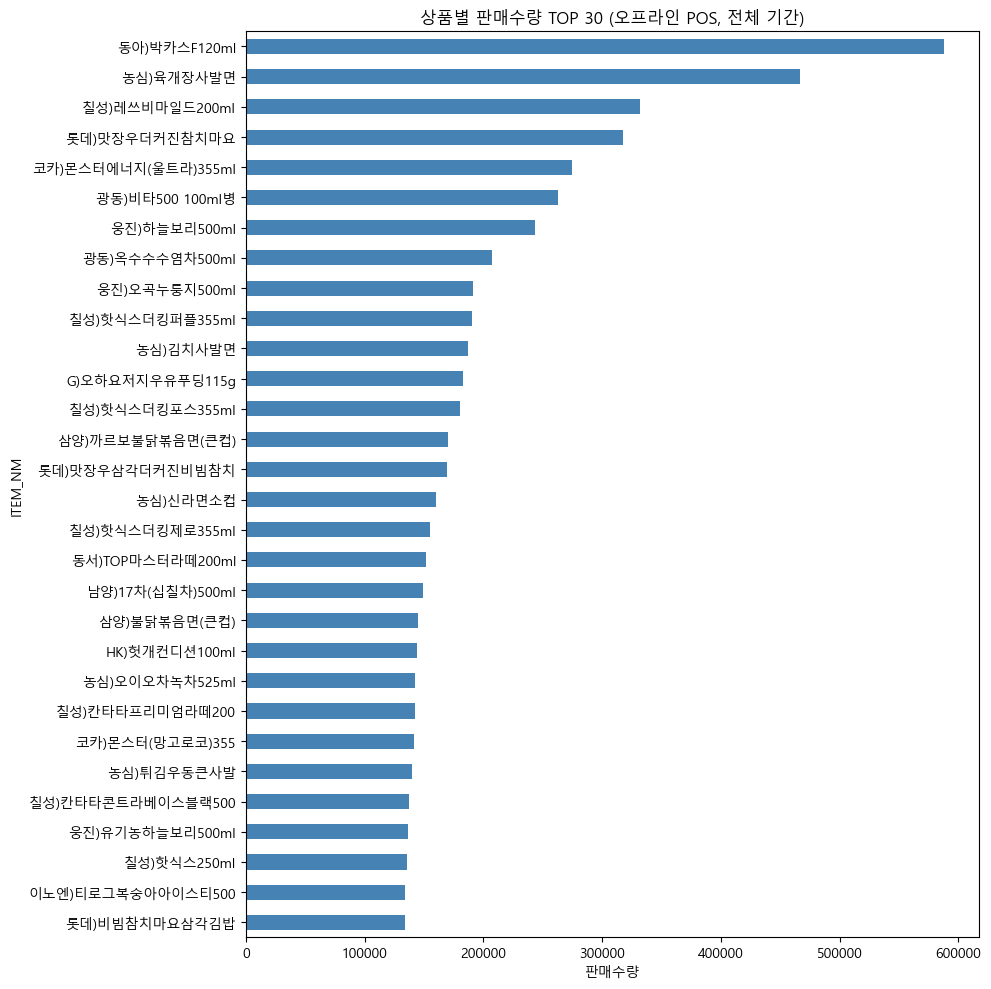

In [12]:
# 상품명 기준 TOP 30
top_items = df.groupby('ITEM_NM')['SALE_QTY'].sum().sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 10))
top_items[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('상품별 판매수량 TOP 30 (오프라인 POS, 전체 기간)')
ax.set_xlabel('판매수량')
plt.tight_layout()
plt.show()

## 3. 네트워크 분석용 데이터 준비

In [13]:
# 대상 중분류 상품이 2개 이상 담긴 거래만 추출
basket_size = df.groupby(TX_KEY)['ITEM_CODE'].count()
multi_tx_idx = basket_size[basket_size >= 2].reset_index()[TX_KEY]

df_multi = df.merge(multi_tx_idx, on=TX_KEY, how='inner')

n_multi = len(multi_tx_idx)
print(f"전체 거래:       {len(basket_size):,}건")
print(f"다중상품 거래:   {n_multi:,}건 ({n_multi/len(basket_size):.1%})")
print(f"분석 대상 행 수: {len(df_multi):,}")

전체 거래:       22,491,420건
다중상품 거래:   7,321,466건 (32.6%)
분석 대상 행 수: 18,932,215


In [14]:
# 거래별 상품명 리스트
df_multi['ITEM_LABEL'] = df_multi['ITEM_NM'].fillna('CODE_' + df_multi['ITEM_CODE'])

basket_items = df_multi.groupby(TX_KEY)['ITEM_LABEL'].apply(list)

print(f"다중상품 거래 수: {len(basket_items):,}")
print("예시:")
for items in basket_items.head(3):
    print(' +'.join(items))

다중상품 거래 수: 7,321,466
예시:
농심)짜파게티범벅 +롯데)맛장우삼각더커진비빔참치
예스)트롤리미니버거10g +해태)초코픽45g
PB)디저트39바나나우유500ml +그린)불닭치즈소시지김밥


## 4. 상품 공동구매 네트워크 구성

In [15]:
# 상품 쌍(pair) 카운팅
pair_counter = Counter()

for items in basket_items:
    unique_items = list(set(items))
    for pair in combinations(sorted(unique_items), 2):
        pair_counter[pair] += 1

print(f"고유 상품 쌍 총 수: {len(pair_counter):,}")
print()
print("가장 많이 함께 구매된 TOP 20 쌍:")
for (a, b), cnt in pair_counter.most_common(20):
    print(f"  {cnt:5d}회  |  {a}  +  {b}")

고유 상품 쌍 총 수: 1,828,840

가장 많이 함께 구매된 TOP 20 쌍:
  25323회  |  덴마크)소화가잘되는바닐라라떼250ml  +  덴마크)소화가잘되는카페라떼250ml
  25274회  |  칠성)핫식스더킹퍼플355ml  +  칠성)핫식스더킹피치355ml
  22757회  |  이노엔)티로그복숭아아이스티500  +  이노엔)티로그청귤아이스티500ml
  21314회  |  농심)김치사발면  +  농심)육개장사발면
  20048회  |  칠성)핫식스더킹제로355ml  +  칠성)핫식스더킹포스355ml
  16167회  |  칠성)칸타타아메리카노200ml  +  칠성)칸타타프리미엄라떼200
  15342회  |  웅진)티즐제로유자그린티500ml  +  웅진)티즐제로피치우롱티500ml
  14843회  |  동서)TOP마스터라떼275ml  +  동서)TOP스위트아메리카노275ml
  14779회  |  동서)TOP마스터라떼275ml  +  동서)TOP블랙275ml
  14659회  |  웅진)티즐제로자몽블랙티500ml  +  웅진)티즐제로피치우롱티500ml
  14204회  |  동원)아이스티(레몬)500ml  +  동원)아이스티(복숭아)500ml
  13354회  |  칠성)핫식스더킹퍼플355ml  +  칠성)핫식스더킹포스355ml
  12923회  |  칠성)핫식스더킹파워355ml  +  칠성)핫식스더킹퍼플355ml
  12828회  |  칠성)칸타타아메리카노275ml  +  칠성)칸타타프리미엄라떼275
  12795회  |  서울)커피타운모카250ml  +  서울)커피타운바닐라250ml
  12358회  |  산토리)짐빔하이볼레몬350ml캔  +  산토리)짐빔하이볼자몽350ml캔
  12225회  |  칠성)핫식스더킹애플홀릭355ml  +  칠성)핫식스더킹퍼플355ml
  11733회  |  웅진)광명찾은결명자차500ml  +  웅진)오곡누룽지500ml
  11211회  |  칠성)칸타타콘트라베이스라떼500  +  칠성)칸타타콘트라베이스블랙

In [16]:
# MIN_COUNT 필터 후 그래프 생성 (연간 전체이므로 1월 기준(20)의 12배 → 200으로 설정)
MIN_COUNT = 200

edges = [(a, b, cnt) for (a, b), cnt in pair_counter.items() if cnt >= MIN_COUNT]
print(f"MIN_COUNT={MIN_COUNT} 기준 엣지 수: {len(edges):,}")

G = nx.Graph()
for a, b, w in edges:
    G.add_edge(a, b, weight=w)

print(f"노드(상품) 수: {G.number_of_nodes():,}")
print(f"엣지(공동구매 쌍) 수: {G.number_of_edges():,}")

MIN_COUNT=200 기준 엣지 수: 9,590
노드(상품) 수: 1,391
엣지(공동구매 쌍) 수: 9,590


## 5. 네트워크 지표 분석

In [17]:
degrees = dict(G.degree())
avg_degree = sum(degrees.values()) / len(degrees)
density = nx.density(G)
clustering = nx.average_clustering(G, weight='weight')
n_components = nx.number_connected_components(G)
largest_cc = max(nx.connected_components(G), key=len)

print("=" * 50)
print("오프라인 POS 네트워크 기본 지표 (전체 기간)")
print("=" * 50)
print(f"노드 수:              {G.number_of_nodes():,}")
print(f"엣지 수:              {G.number_of_edges():,}")
print(f"평균 degree:          {avg_degree:.2f}")
print(f"네트워크 밀도:        {density:.6f}")
print(f"평균 클러스터링 계수: {clustering:.4f}")
print(f"연결 컴포넌트 수:     {n_components}")
print(f"최대 컴포넌트 크기:   {len(largest_cc)}개 노드")

오프라인 POS 네트워크 기본 지표 (전체 기간)
노드 수:              1,391
엣지 수:              9,590
평균 degree:          13.79
네트워크 밀도:        0.009920
평균 클러스터링 계수: 0.0149
연결 컴포넌트 수:     186
최대 컴포넌트 크기:   918개 노드


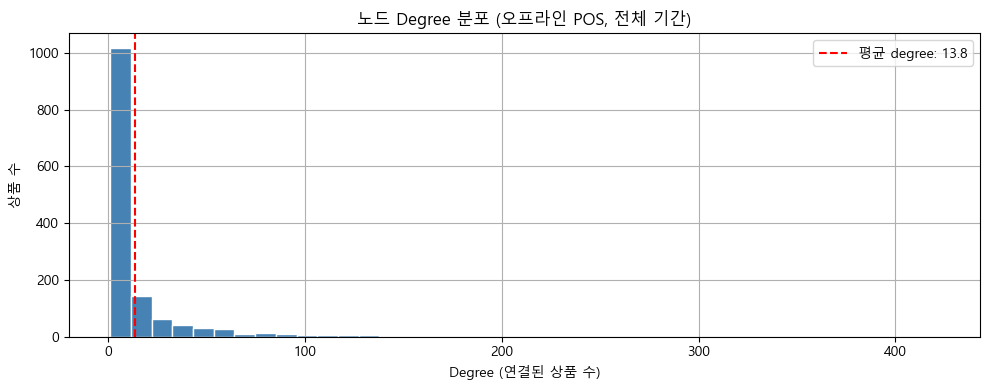

In [18]:
# Degree 분포
fig, ax = plt.subplots(figsize=(10, 4))
pd.Series(list(degrees.values())).hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(avg_degree, color='red', linestyle='--', label=f'평균 degree: {avg_degree:.1f}')
ax.set_title('노드 Degree 분포 (오프라인 POS, 전체 기간)')
ax.set_xlabel('Degree (연결된 상품 수)')
ax.set_ylabel('상품 수')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# 허브 상품 — degree 기준 TOP 20
print("=== 허브 제품 TOP 20 (degree 기준) ===")
for rank, (item, deg) in enumerate(
    sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:20], 1
):
    print(f"  {rank:2d}위  degree={deg:4d}  |  {item}")

=== 허브 제품 TOP 20 (degree 기준) ===
   1위  degree= 422  |  농심)육개장사발면
   2위  degree= 277  |  롯데)맛장우더커진참치마요
   3위  degree= 187  |  농심)김치사발면
   4위  degree= 172  |  농심)새우깡90g
   5위  degree= 171  |  오리온)포카칩오리지널60g
   6위  degree= 165  |  농심)매운새우깡90g
   7위  degree= 164  |  롯데)맛장우삼각더커진비빔참치
   8위  degree= 162  |  삼양)까르보불닭볶음면(큰컵)
   9위  degree= 155  |  오리온)태양의맛썬핫스파이시80g
  10위  degree= 146  |  오뚜기)참깨라면큰컵
  11위  degree= 145  |  농심)튀김우동큰사발
  12위  degree= 144  |  농심)신라면소컵
  13위  degree= 139  |  농심)신라면큰사발
  14위  degree= 135  |  오리온)초코송이
  15위  degree= 134  |  해태)허니버터칩60g
  16위  degree= 131  |  삼양)불닭볶음면(큰컵)
  17위  degree= 130  |  오리온)포카칩양파맛60g
  18위  degree= 129  |  농심)새우탕큰사발
  19위  degree= 121  |  그린)더커진울진대게딱지장삼각
  20위  degree= 121  |  롯데)비빔참치마요삼각김밥


In [20]:
# 허브 상품 — strength(공동구매 빈도 합계) 기준 TOP 20
strength = {n: sum(d['weight'] for _, _, d in G.edges(n, data=True)) for n in G.nodes()}

print("=== 허브 제품 TOP 20 (strength 기준) ===")
for rank, (item, s) in enumerate(
    sorted(strength.items(), key=lambda x: x[1], reverse=True)[:20], 1
):
    print(f"  {rank:2d}위  strength={s:7,d}  |  {item}")

=== 허브 제품 TOP 20 (strength 기준) ===
   1위  strength=348,463  |  농심)육개장사발면
   2위  strength=216,080  |  롯데)맛장우더커진참치마요
   3위  strength=125,927  |  농심)김치사발면
   4위  strength=109,035  |  롯데)맛장우삼각더커진비빔참치
   5위  strength=108,197  |  농심)새우깡90g
   6위  strength= 99,720  |  삼양)까르보불닭볶음면(큰컵)
   7위  strength= 98,049  |  오리온)포카칩오리지널60g
   8위  strength= 97,466  |  칠성)핫식스더킹퍼플355ml
   9위  strength= 93,957  |  농심)신라면소컵
  10위  strength= 92,850  |  농심)매운새우깡90g
  11위  strength= 90,204  |  오리온)태양의맛썬핫스파이시80g
  12위  strength= 89,291  |  농심)튀김우동큰사발
  13위  strength= 87,298  |  오뚜기)참깨라면큰컵
  14위  strength= 86,955  |  삼양)불닭볶음면(큰컵)
  15위  strength= 83,099  |  농심)신라면큰사발
  16위  strength= 81,252  |  농심)새우탕큰사발
  17위  strength= 76,540  |  칠성)핫식스더킹포스355ml
  18위  strength= 76,360  |  롯데)맛장우삼각더커진소고기고추장
  19위  strength= 73,419  |  오리온)포카칩양파맛60g
  20위  strength= 72,684  |  롯데)더커진육즙가득삼겹살삼각


In [21]:
# Betweenness Centrality — 연결 브릿지 역할 상품
print("Betweenness centrality 계산 중...")
G_sub = G.subgraph(largest_cc)
betweenness = nx.betweenness_centrality(
    G_sub, weight='weight', k=min(300, G_sub.number_of_nodes())
)

print("=== 매개중심성 TOP 10 (betweenness centrality) ===")
for rank, (item, bc) in enumerate(
    sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10], 1
):
    print(f"  {rank:2d}위  bc={bc:.4f}  |  {item}")

Betweenness centrality 계산 중...
=== 매개중심성 TOP 10 (betweenness centrality) ===
   1위  bc=0.2150  |  농심)육개장사발면
   2위  bc=0.1155  |  롯데)맛장우더커진참치마요
   3위  bc=0.0544  |  동아)박카스F120ml
   4위  bc=0.0479  |  G)오하요저지우유푸딩115g
   5위  bc=0.0423  |  롯데)아몬드빼빼로37g
   6위  bc=0.0414  |  코카)몬스터에너지(울트라)355ml
   7위  bc=0.0368  |  CJ)둥근햇반210g
   8위  bc=0.0332  |  농심)새우깡90g
   9위  bc=0.0322  |  농심)매운새우깡90g
  10위  bc=0.0319  |  오리온)닥터유에너지바40g


## 6. 네트워크 시각화

시각화 대상: 노드 80개, 엣지 1746개


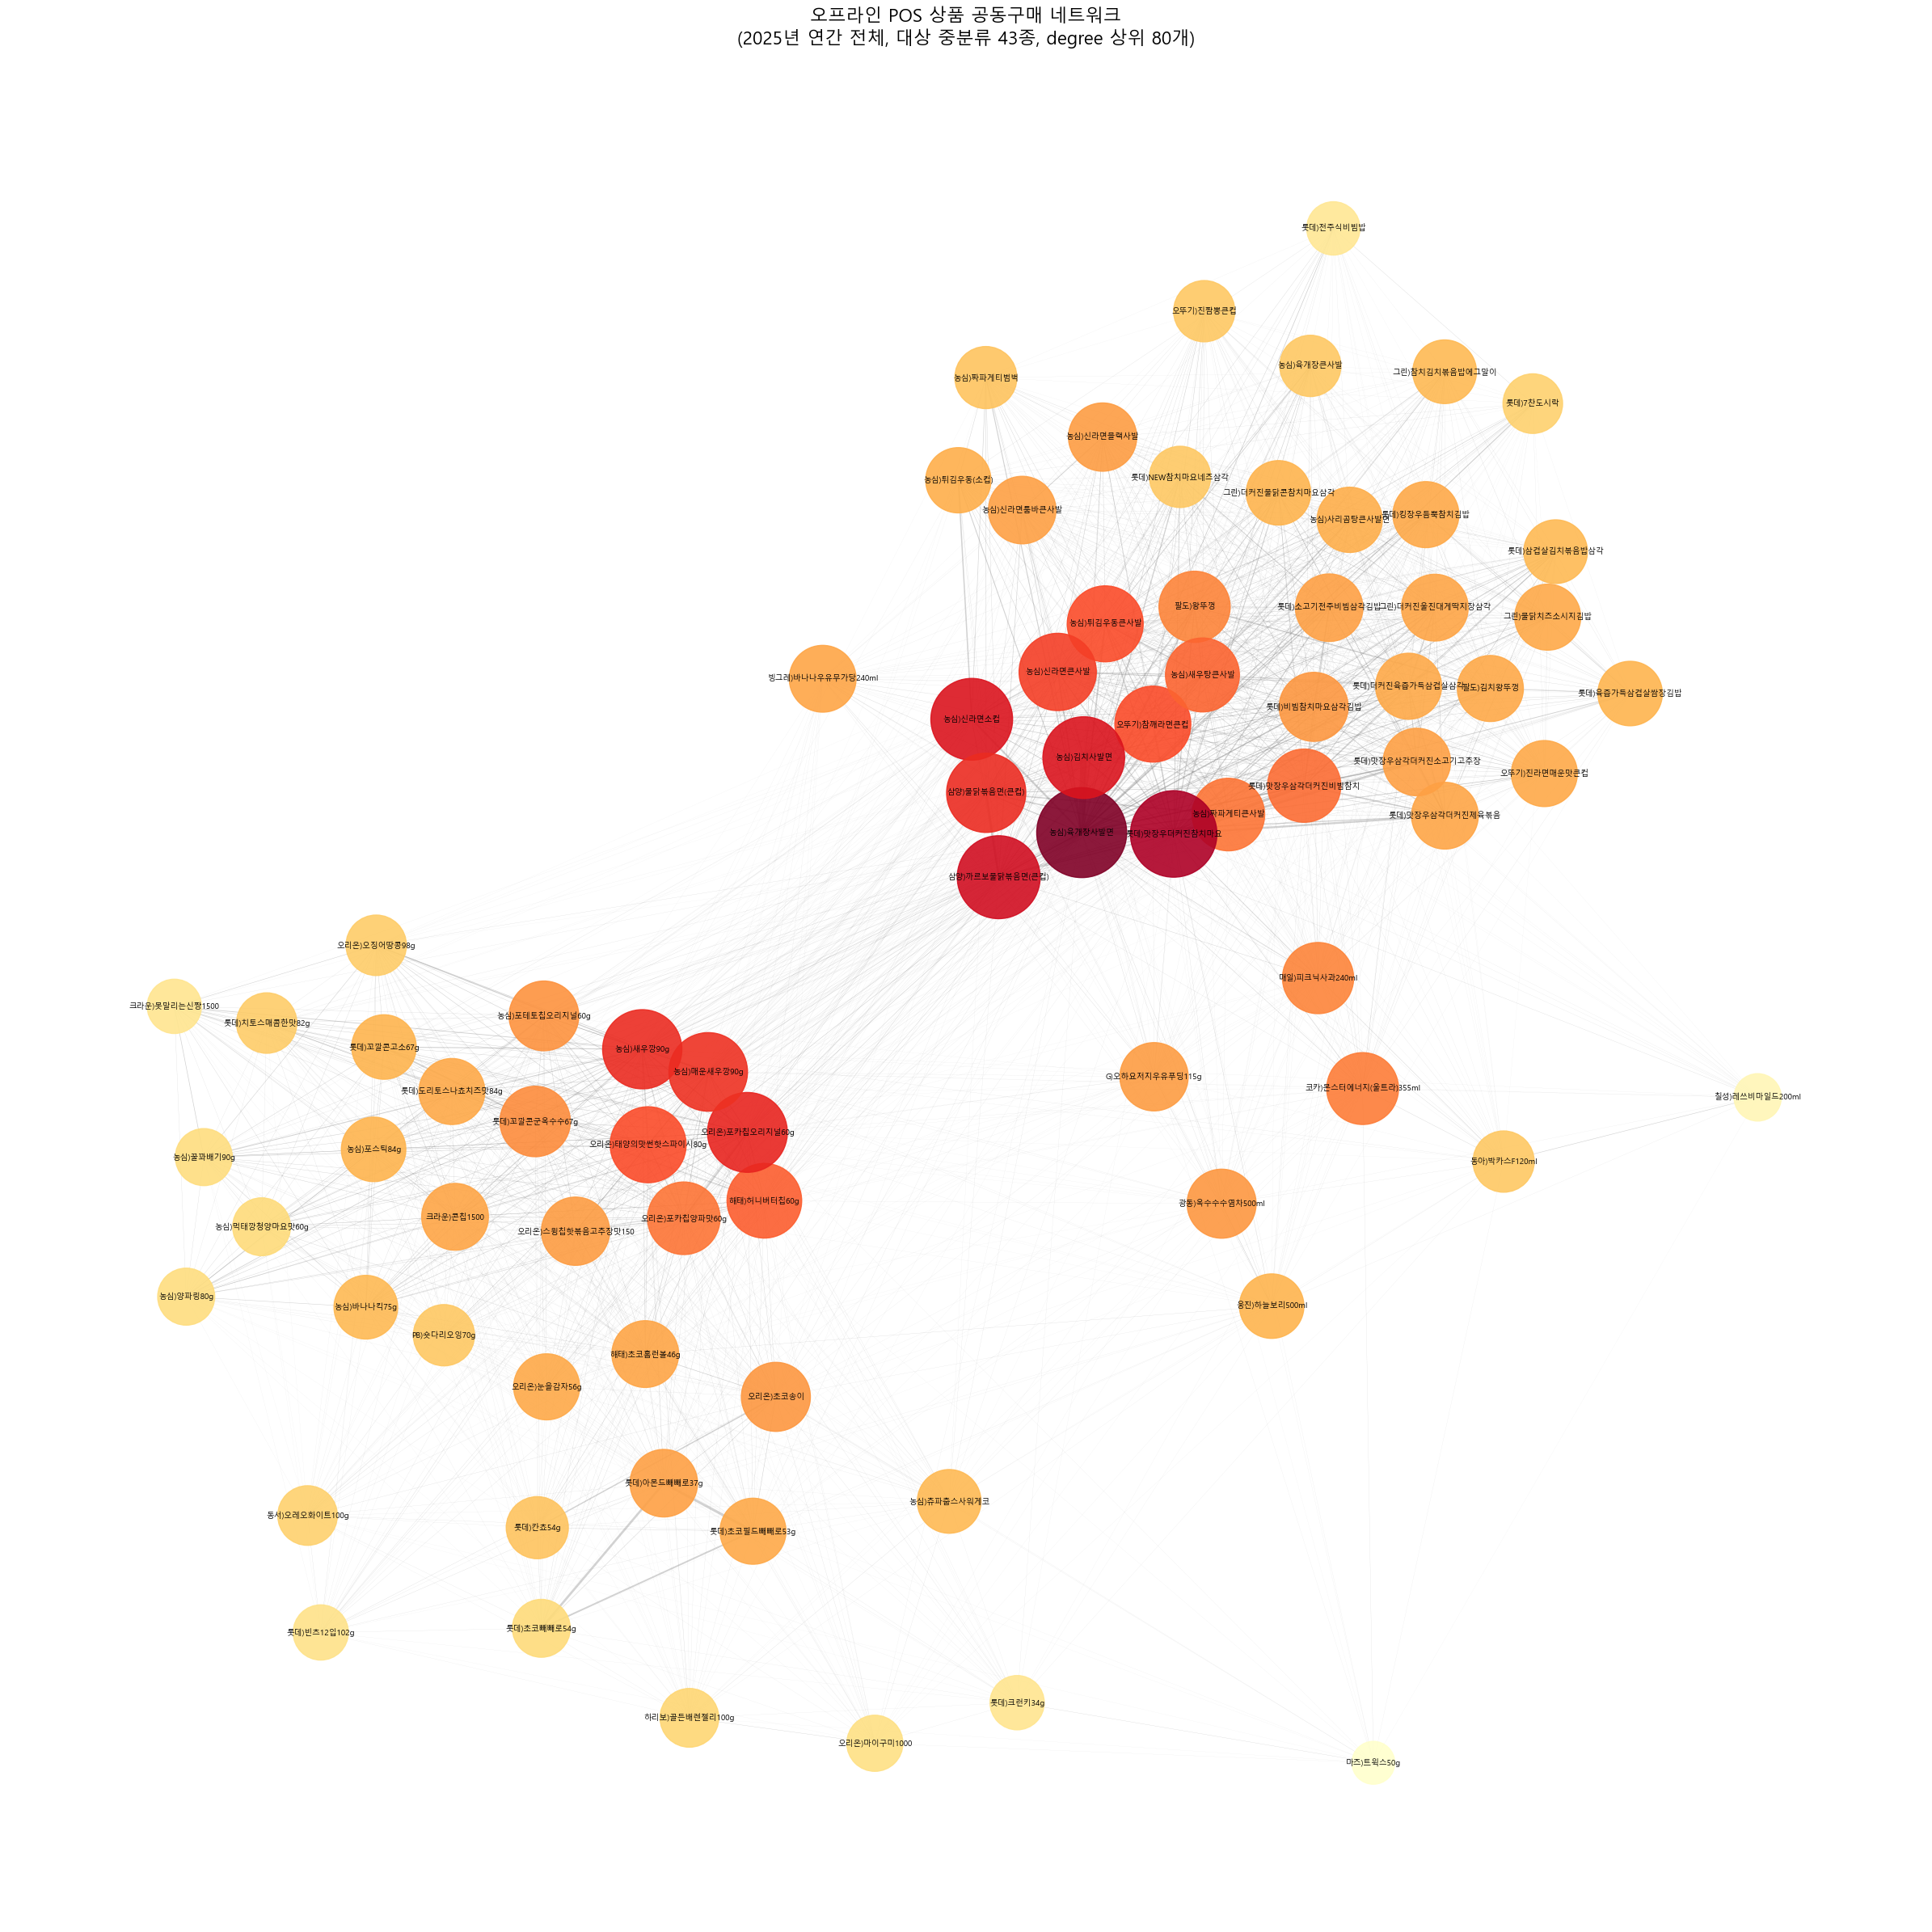

저장 완료: offline_network_v3_full.png


In [22]:
# degree 상위 80개 노드만 시각화
VIZ_MAX_NODES = 80

top_nodes = [n for n, _ in sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:VIZ_MAX_NODES]]
G_viz = G.subgraph(top_nodes)

print(f"시각화 대상: 노드 {G_viz.number_of_nodes()}개, 엣지 {G_viz.number_of_edges()}개")

fig, ax = plt.subplots(figsize=(24, 24))

pos = nx.spring_layout(G_viz, k=2.5, seed=42, iterations=100)
deg_viz = dict(G_viz.degree())

node_size = [deg_viz[n] * 80 + 100 for n in G_viz.nodes()]
edge_weights = [G_viz[u][v]['weight'] for u, v in G_viz.edges()]
max_w = max(edge_weights) if edge_weights else 1
edge_width = [w / max_w * 6 for w in edge_weights]

nx.draw_networkx_nodes(
    G_viz, pos,
    node_size=node_size,
    node_color=list(deg_viz.values()),
    cmap='YlOrRd', alpha=0.9, ax=ax
)
nx.draw_networkx_edges(
    G_viz, pos,
    width=edge_width, alpha=0.35, edge_color='gray', ax=ax
)
nx.draw_networkx_labels(
    G_viz, pos,
    font_size=7, font_family='Malgun Gothic', ax=ax
)

ax.set_title(
    f'오프라인 POS 상품 공동구매 네트워크\n(2025년 연간 전체, 대상 중분류 43종, degree 상위 {VIZ_MAX_NODES}개)',
    fontsize=16, pad=20
)
ax.axis('off')
plt.tight_layout()
plt.savefig('offline_network_v3_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: offline_network_v3_full.png")

## 6-2. 인터랙티브 네트워크 시각화 (HTML 전체 노드)

In [23]:
!pip install pyvis -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\eun03\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [24]:
from pyvis.network import Network

# degree 기준 색상 구간 설정
def degree_color(deg, max_deg):
    ratio = deg / max_deg
    if ratio >= 0.7:
        return '#d73027'   # 빨강 — 초고연결
    elif ratio >= 0.4:
        return '#fc8d59'   # 주황
    elif ratio >= 0.2:
        return '#fee090'   # 노랑
    else:
        return '#91bfdb'   # 파랑 — 저연결

max_deg = max(degrees.values())

net = Network(height='900px', width='100%', bgcolor='#1a1a2e', font_color='white', notebook=False)
net.barnes_hut(gravity=-8000, central_gravity=0.3, spring_length=120, spring_strength=0.01)

# 노드 추가
for node in G.nodes():
    deg = degrees[node]
    s = strength[node]
    size = 8 + deg * 0.4
    color = degree_color(deg, max_deg)
    net.add_node(
        node,
        label=node,
        title=f"{node}<br>degree: {deg}<br>strength: {s:,}",
        size=size,
        color=color,
        font={'size': 10}
    )

# 엣지 추가
max_w = max(d['weight'] for _, _, d in G.edges(data=True))
for u, v, d in G.edges(data=True):
    w = d['weight']
    net.add_edge(
        u, v,
        value=w,
        title=f"공동구매: {w:,}회",
        color='rgba(200,200,200,0.25)'
    )

net.show_buttons(filter_=['physics'])
OUTPUT_PATH = 'offline_network_interactive.html'
net.save_graph(OUTPUT_PATH)
print(f"저장 완료: {OUTPUT_PATH}  (노드 {G.number_of_nodes():,}개 / 엣지 {G.number_of_edges():,}개)")

저장 완료: offline_network_interactive.html  (노드 1,391개 / 엣지 9,590개)


## 7. 중분류 단위 네트워크 (상품명 대신 중분류로 노드 구성)

In [25]:
# 중분류 단위 공동구매 네트워크
# 같은 거래에 담긴 중분류 쌍 카운팅
basket_cats = df_multi.groupby(TX_KEY)['ITEM_MDDV_NM'].apply(list)

cat_pair_counter = Counter()
for cats in basket_cats:
    unique_cats = list(set(cats))
    for pair in combinations(sorted(unique_cats), 2):
        cat_pair_counter[pair] += 1

print(f"고유 중분류 쌍 수: {len(cat_pair_counter):,}")
print()
print("중분류 공동구매 TOP 20:")
for (a, b), cnt in cat_pair_counter.most_common(20):
    print(f"  {cnt:6d}회  |  {a}  +  {b}")

고유 중분류 쌍 수: 780

중분류 공동구매 TOP 20:
  496108회  |  삼각김밥  +  용기면
  385752회  |  비스킷류  +  스낵류
  255428회  |  김밥  +  용기면
  234410회  |  스낵류  +  용기면
  179990회  |  도시락  +  용기면
  165826회  |  스낵류  +  젤리류
  162252회  |  비스킷류  +  초콜릿
  153780회  |  스낵류  +  초콜릿
  123617회  |  비스킷류  +  젤리류
  119933회  |  스낵류  +  차음료
  119756회  |  젤리류  +  초콜릿
  116130회  |  비스킷류  +  용기면
   99198회  |  냉장간식  +  용기면
   98094회  |  용기면  +  차음료
   91668회  |  기능성드링크  +  용기면
   86628회  |  삼각김밥  +  스낵류
   82929회  |  기능성드링크  +  스낵류
   82738회  |  비스킷류  +  차음료
   81634회  |  삼각김밥  +  샌드위치
   81078회  |  김밥  +  삼각김밥


In [26]:
# 중분류 네트워크 그래프
MIN_CAT_COUNT = 100

cat_edges = [(a, b, cnt) for (a, b), cnt in cat_pair_counter.items() if cnt >= MIN_CAT_COUNT]
G_cat = nx.Graph()
for a, b, w in cat_edges:
    G_cat.add_edge(a, b, weight=w)

cat_degrees = dict(G_cat.degree())
avg_cat_degree = sum(cat_degrees.values()) / len(cat_degrees)

print(f"중분류 노드 수: {G_cat.number_of_nodes()}")
print(f"중분류 엣지 수: {G_cat.number_of_edges()}")
print(f"평균 degree:    {avg_cat_degree:.2f}")
print()
print("허브 중분류 TOP 10:")
for rank, (cat, deg) in enumerate(
    sorted(cat_degrees.items(), key=lambda x: x[1], reverse=True)[:10], 1
):
    print(f"  {rank:2d}위  degree={deg}  |  {cat}")

중분류 노드 수: 40
중분류 엣지 수: 740
평균 degree:    37.00

허브 중분류 TOP 10:
   1위  degree=39  |  삼각김밥
   2위  degree=39  |  용기면
   3위  degree=39  |  비스킷류
   4위  degree=39  |  젤리류
   5위  degree=39  |  가공우유
   6위  degree=39  |  김밥
   7위  degree=39  |  기능성드링크
   8위  degree=39  |  도시락
   9위  degree=39  |  스낵류
  10위  degree=39  |  초콜릿


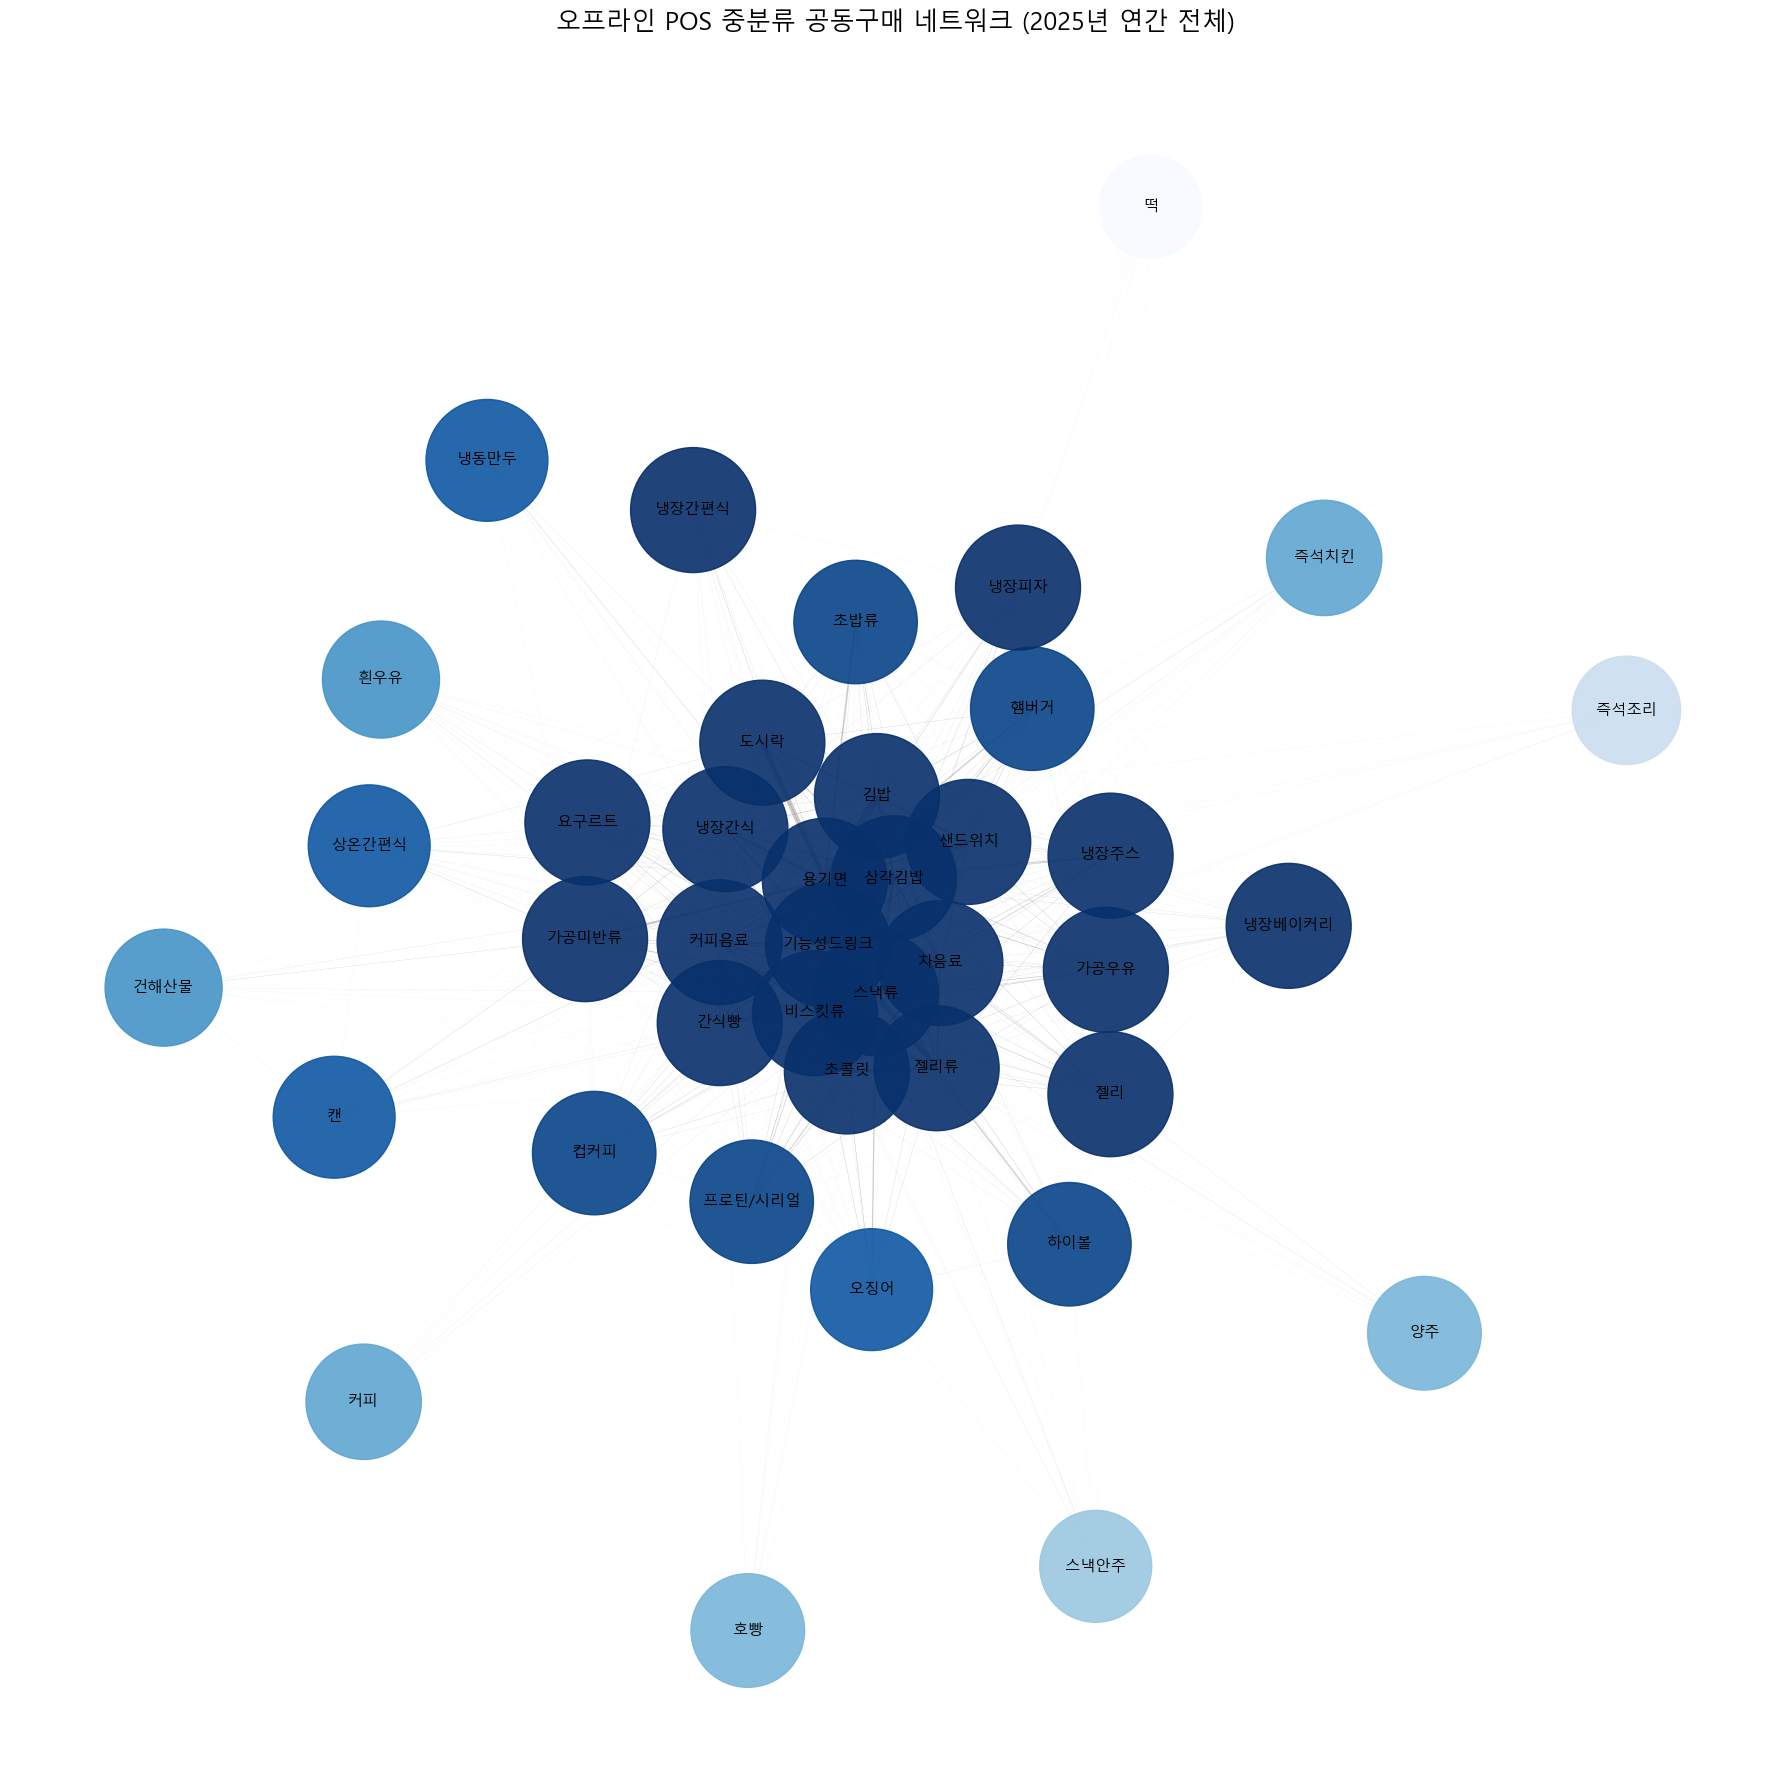

저장 완료: offline_category_network_v3_full.png


In [27]:
# 중분류 네트워크 시각화
fig, ax = plt.subplots(figsize=(18, 18))

pos_cat = nx.spring_layout(G_cat, k=3, seed=42, iterations=200)

cat_node_size = [cat_degrees[n] * 200 + 300 for n in G_cat.nodes()]
cat_edge_weights = [G_cat[u][v]['weight'] for u, v in G_cat.edges()]
max_cw = max(cat_edge_weights) if cat_edge_weights else 1
cat_edge_width = [w / max_cw * 10 for w in cat_edge_weights]

nx.draw_networkx_nodes(
    G_cat, pos_cat,
    node_size=cat_node_size,
    node_color=list(cat_degrees.values()),
    cmap='Blues', alpha=0.9, ax=ax
)
nx.draw_networkx_edges(
    G_cat, pos_cat,
    width=cat_edge_width, alpha=0.4, edge_color='gray', ax=ax
)
nx.draw_networkx_labels(
    G_cat, pos_cat,
    font_size=11, font_family='Malgun Gothic', ax=ax
)

ax.set_title('오프라인 POS 중분류 공동구매 네트워크 (2025년 연간 전체)', fontsize=18, pad=20)
ax.axis('off')
plt.tight_layout()
plt.savefig('offline_category_network_v3_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: offline_category_network_v3_full.png")

## 8. 퀵커머스(지윤)와 비교할 요약 지표

In [28]:
basket_size_all = df.groupby(TX_KEY)['ITEM_CODE'].count()
basket_amt_all = df.groupby(TX_KEY)['SALE_AMT'].sum()

summary = {
    '분석 기간':             f"{df['SALE_DATE'].min()} ~ {df['SALE_DATE'].max()} (오프라인 POS 연간)",
    '분석 중분류 수':        f"{len(TARGET_CATEGORIES)}종",
    '총 거래 수':            f"{len(basket_size_all):,}건",
    '평균 basket size':     f"{basket_size_all.mean():.2f}개",
    '다중상품 거래 비율':     f"{(basket_size_all >= 2).mean():.1%}",
    '평균 결제금액':         f"{basket_amt_all.mean():,.0f}원",
    '[상품] 노드 수':        f"{G.number_of_nodes():,}개",
    '[상품] 엣지 수':        f"{G.number_of_edges():,}개",
    '[상품] 평균 degree':   f"{avg_degree:.2f}",
    '[상품] 네트워크 밀도':  f"{density:.6f}",
    '[상품] 클러스터링 계수':f"{clustering:.4f}",
    '[중분류] 노드 수':      f"{G_cat.number_of_nodes()}개",
    '[중분류] 엣지 수':      f"{G_cat.number_of_edges()}개",
    '[중분류] 평균 degree': f"{avg_cat_degree:.2f}",
}

print("=" * 60)
print("오프라인 POS 요약 지표 (지윤이랑 비교용)")
print("=" * 60)
for k, v in summary.items():
    print(f"  {k:<25}: {v}")

오프라인 POS 요약 지표 (지윤이랑 비교용)
  분석 기간                    : 20250101 ~ 20251231 (오프라인 POS 연간)
  분석 중분류 수                 : 43종
  총 거래 수                   : 22,491,420건
  평균 basket size           : 1.52개
  다중상품 거래 비율               : 32.6%
  평균 결제금액                  : 3,782원
  [상품] 노드 수                : 1,391개
  [상품] 엣지 수                : 9,590개
  [상품] 평균 degree           : 13.79
  [상품] 네트워크 밀도             : 0.009920
  [상품] 클러스터링 계수            : 0.0149
  [중분류] 노드 수               : 40개
  [중분류] 엣지 수               : 740개
  [중분류] 평균 degree          : 37.00
